<a href="https://colab.research.google.com/github/Huii0529/MSc_STQD6324_DataManagement_FinalReport/blob/main/P167347_STQD6324_DataManagement_FinalReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.0 INTRODUCTION**

## **Uneven Growth: Analyzing Population Concentration and Regional Disparities in Malaysia**

Population distribution plays a significant role in shaping economic performance, infrastructure development, and regional planning. In Malaysia, population and economic activities are not evenly distributed across states, resulting in varying levels of growth and development.

This study examines the distribution of population across Malaysian states and territories from 2015 to 2023 and investigates the relationship between population size and state-level Gross Domestic Product (GDP). The analysis aims to identify patterns of population concentration and assess whether higher population levels are associated with stronger economic output across states.

Datasets:
1. https://data.gov.my/data-catalogue/population_malaysia
2. https://data.gov.my/data-catalogue/population_state
3. https://data.gov.my/data-catalogue/gdp_state_real_supply

## **1.1 PROBLEM STATEMENT**

- Are populations evenly distributed across Malaysian states?
- Is population size correlated with state GDP?

## **1.2 HYPOTHESIS TESTING**

- H₀: Population size is not related to GDP.
- H₁: States with larger populations have higher GDP.

# **2.0 DATA COLLECTION**

Three datasets were retrieved from the Department of Statistics Malaysia (DOSM)
Open Data portal (OpenDOSM). These datasets provide authoritative demographic
and economic statistics at both national and state levels. The datasets were
combined to support an integrated analysis of population distribution and
regional economic disparities.

In [46]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Read CSV data by using URL
urls = {
    "population_malaysia": "https://storage.dosm.gov.my/population/population_malaysia.csv",
    "population_state": "https://storage.dosm.gov.my/population/population_state.csv",
    "gdp": "https://storage.dosm.gov.my/gdp/gdp_state_real_supply.csv"
}

# Load datasets into dictionary
dataframes = {name: pd.read_csv(url) for name, url in urls.items()}

# Convert date column to datetime
for name, df in dataframes.items():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')

## **2.1 Data Cleaning and Preparation**

In [48]:
# Check Data Structure

def check_structure(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nColumns and Data Types:")
    print(df.dtypes)
    print("\nFirst 5 Rows:")
    print(df.head())
    print("\nMissing Values:")
    print(df.isna().sum())
    print("\nUnique values per column:")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()}")
    print("\n" + "="*50 + "\n")

# Apply to all datasets
for name, df in dataframes.items():
    check_structure(df, name)

--- population_malaysia ---
Shape: (17415, 5)

Columns and Data Types:
date          datetime64[ns]
sex                   object
age                   object
ethnicity             object
population           float64
dtype: object

First 5 Rows:
        date   sex      age ethnicity  population
0 1970-01-01  both  overall   overall     10881.8
1 1970-01-01  both      0-4   overall      1702.4
2 1970-01-01  both      5-9   overall      1690.3
3 1970-01-01  both    10-14   overall      1454.7
4 1970-01-01  both    15-19   overall      1197.6

Missing Values:
date          0
sex           0
age           0
ethnicity     0
population    0
dtype: int64

Unique values per column:
date: 56
sex: 3
age: 21
ethnicity: 9
population: 6955


--- population_state ---
Shape: (263679, 6)

Columns and Data Types:
state                 object
date          datetime64[ns]
sex                   object
age                   object
ethnicity             object
population           float64
dtype: object

Firs

In [49]:
# Drop rows where 'state' is 'supra' from the GDP DataFrame
dataframes['gdp'] = dataframes['gdp'][dataframes['gdp']['state'] != 'supra']

Dropping 'Supra' values will not impact the overall results, as this entry does not represent a specific Malaysian state, and all other states have complete GDP data.

In [50]:
# Fill categorical missing values
for col in ['state','sex','age','ethnicity','series','sector']:
    for df in dataframes.values():
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

# Fill numeric missing values using interpolation or median
dataframes['population_state']['population'] = dataframes['population_state'].groupby(['state','age'])['population'].transform(lambda x: x.interpolate())
dataframes['population_malaysia']['population'] = dataframes['population_malaysia'].groupby(['age'])['population'].transform(lambda x: x.interpolate())
gdp_abs = dataframes['gdp'][dataframes['gdp']['series']=='abs'].copy()
gdp_abs['value'] = gdp_abs.groupby(['state','sector'])['value'].transform(lambda x: x.interpolate())

In [51]:
#Filter by year
START_YEAR = 2015
END_YEAR = 2023

# Filter population and GDP (gdp_abs is already filtered for 'abs' series from previous steps)
pop_state_filtered = dataframes['population_state'][(dataframes['population_state']['date'].dt.year >= START_YEAR) & (dataframes['population_state']['date'].dt.year <= END_YEAR)]
pop_malaysia_filtered = dataframes['population_malaysia'][(dataframes['population_malaysia']['date'].dt.year >= START_YEAR) & (dataframes['population_malaysia']['date'].dt.year <= END_YEAR)]
gdp_filtered = gdp_abs[(gdp_abs['date'].dt.year >= START_YEAR) & (gdp_abs['date'].dt.year <= END_YEAR)]

# Aggregate population by state-year (overall age)
pop_state_agg = pop_state_filtered[pop_state_filtered['age']=='overall'].groupby(['state','date']).agg({'population':'sum'}).reset_index()

# Aggregate GDP by state-year (sum across all sectors to get total GDP per state/date)
gdp_total = gdp_filtered.groupby(['state','date']).agg({'value':'sum'}).reset_index()

# Merge datasets
merged_df = pd.merge(pop_state_agg, gdp_total, on=['state','date'], how='left')
merged_df['year'] = merged_df['date'].dt.year

# Fill remaining missing numeric values with median
merged_df['population'] = merged_df['population'].fillna(merged_df['population'].median())
merged_df['value'] = merged_df['value'].fillna(merged_df['value'].median())

merged_df.head()

,state,date,population,value,year
0,Johor,2015-01-01,14441.1,220004.442,2015
1,Johor,2016-01-01,14606.5,233364.454,2016
2,Johor,2017-01-01,14789.0,247122.653,2017
3,Johor,2018-01-01,14997.3,261171.889,2018
4,Johor,2019-01-01,15045.4,268451.875,2019


In [52]:
display(merged_df)

,state,date,population,value,year
0,Johor,2015-01-01,14441.1,220004.442,2015
1,Johor,2016-01-01,14606.5,233364.454,2016
2,Johor,2017-01-01,14789.0,247122.653,2017
3,Johor,2018-01-01,14997.3,261171.889,2018
4,Johor,2019-01-01,15045.4,268451.875,2019
...,...,...,...,...,...
139,W.P. Putrajaya,2019-01-01,414.8,110880.207,2019
140,W.P. Putrajaya,2020-01-01,436.7,110880.207,2020
141,W.P. Putrajaya,2021-01-01,460.7,110880.207,2021
142,W.P. Putrajaya,2022-01-01,467.9,110880.207,2022


## **2.3 Hive Views**

In [69]:
# Import pyspark library

import pyspark

In [54]:
# Enable Hive View from pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MalaysiaPopulationGDP") \
    .enableHiveSupport() \
    .getOrCreate()

In [55]:
# Hive View
# Convert Pandas DataFrames to Spark DataFrames and then create temporary views
spark_population_malaysia = spark.createDataFrame(dataframes['population_malaysia'])
spark_population_state = spark.createDataFrame(dataframes['population_state'])
spark_gdp = spark.createDataFrame(dataframes['gdp'])

spark_population_malaysia.createOrReplaceTempView("population_malaysia")
spark_population_state.createOrReplaceTempView("population_state")
spark_gdp.createOrReplaceTempView("gdp")

In [56]:
# Latest Population by State

spark.sql("""
CREATE OR REPLACE TEMP VIEW vw_latest_population_state AS
SELECT
    state,
    date,
    population
FROM population_state
WHERE date = (
    SELECT MAX(date)
    FROM population_state
)
AND sex = 'both'
AND age = 'overall'
AND ethnicity = 'overall';
""")

spark.sql("""SELECT * FROM vw_latest_population_state
ORDER BY population DESC
""").show(50, truncate=False)

+-----------------+-------------------+----------+
|state            |date               |population|
+-----------------+-------------------+----------+
|Selangor         |2025-01-01 00:00:00|7406.8    |
|Johor            |2025-01-01 00:00:00|4205.9    |
|Sabah            |2025-01-01 00:00:00|3759.6    |
|Perak            |2025-01-01 00:00:00|2574.9    |
|Sarawak          |2025-01-01 00:00:00|2529.8    |
|Kedah            |2025-01-01 00:00:00|2228.0    |
|W.P. Kuala Lumpur|2025-01-01 00:00:00|2074.1    |
|Kelantan         |2025-01-01 00:00:00|1907.7    |
|Pulau Pinang     |2025-01-01 00:00:00|1803.3    |
|Pahang           |2025-01-01 00:00:00|1678.2    |
|Terengganu       |2025-01-01 00:00:00|1246.9    |
|Negeri Sembilan  |2025-01-01 00:00:00|1244.6    |
|Melaka           |2025-01-01 00:00:00|1052.5    |
|Perlis           |2025-01-01 00:00:00|297.8     |
|W.P. Putrajaya   |2025-01-01 00:00:00|120.8     |
|W.P. Labuan      |2025-01-01 00:00:00|100.9     |
+-----------------+------------

This view displays the latest total population for each Malaysian state. It filters the dataset to include only the overall population across all ages, genders, and ethnic groups.



In [57]:
# Top 10 Most Populated States

spark.sql("""CREATE OR REPLACE TEMP VIEW vw_top10_population_states AS
SELECT
    state,
    population
FROM population_state
WHERE sex = 'both'
AND age = 'overall'
AND ethnicity = 'overall'
AND date = (
    SELECT MAX(date)
    FROM population_state
)
ORDER BY population DESC
LIMIT 10;
""")

spark.sql("""SELECT * FROM vw_top10_population_states
""").show(truncate=False)

+-----------------+----------+
|state            |population|
+-----------------+----------+
|Selangor         |7406.8    |
|Johor            |4205.9    |
|Sabah            |3759.6    |
|Perak            |2574.9    |
|Sarawak          |2529.8    |
|Kedah            |2228.0    |
|W.P. Kuala Lumpur|2074.1    |
|Kelantan         |1907.7    |
|Pulau Pinang     |1803.3    |
|Pahang           |1678.2    |
+-----------------+----------+



This view identifies the ten states with the highest population based on the most recent available data.

In [58]:
# Population by Ethnicity

spark.sql("""CREATE OR REPLACE TEMP VIEW vw_population_ethnicity AS
SELECT
    state,
    ethnicity,
    population
FROM population_state
WHERE sex = 'both'
AND age = 'overall'
AND ethnicity <> 'overall'
AND date = (
    SELECT MAX(date)
    FROM population_state
);
""")

spark.sql("""SELECT * FROM vw_population_ethnicity
ORDER BY state, population DESC
""").show(10, truncate=False)

+-----+----------------+----------+
|state|ethnicity       |population|
+-----+----------------+----------+
|Johor|bumi_malay      |2277.7    |
|Johor|chinese         |1213.7    |
|Johor|other_noncitizen|385.1     |
|Johor|indian          |248.1     |
|Johor|bumi_other      |61.3      |
|Johor|other_citizen   |19.9      |
|Kedah|bumi_malay      |1711.3    |
|Kedah|chinese         |246.7     |
|Kedah|indian          |128.4     |
|Kedah|other_noncitizen|111.0     |
+-----+----------------+----------+
only showing top 10 rows


This view shows the population distribution by ethnicity for each state using the latest available population data.

In [59]:
# Population by Age Group

spark.sql("""CREATE OR REPLACE TEMP VIEW vw_population_age_group AS
SELECT
    state,
    age,
    population
FROM population_state
WHERE sex = 'both'
AND ethnicity = 'overall'
AND age <> 'overall'
AND date = (
    SELECT MAX(date)
    FROM population_state
);
""")

spark.sql("""SELECT * FROM vw_population_age_group
ORDER BY state, age
""").show(10, truncate=False)

+-----+-----+----------+
|state|age  |population|
+-----+-----+----------+
|Johor|0-4  |251.7     |
|Johor|10-14|321.8     |
|Johor|15-19|347.0     |
|Johor|20-24|405.5     |
|Johor|25-29|404.7     |
|Johor|30-34|348.3     |
|Johor|35-39|328.1     |
|Johor|40-44|308.0     |
|Johor|45-49|252.7     |
|Johor|5-9  |306.2     |
+-----+-----+----------+
only showing top 10 rows


This view summarizes the population across different age groups for each state, allowing demographic age analysis.

In [60]:
# Male vs Female Population

spark.sql("""CREATE OR REPLACE TEMP VIEW vw_gender_population AS
SELECT
    state,
    sex,
    population
FROM population_state
WHERE age = 'overall'
AND ethnicity = 'overall'
AND sex <> 'both'
AND date = (
    SELECT MAX(date)
    FROM population_state
);
""")

spark.sql("""SELECT * FROM vw_gender_population
ORDER BY state
""").show(10, truncate=False)

+---------------+------+----------+
|state          |sex   |population|
+---------------+------+----------+
|Johor          |female|1951.4    |
|Johor          |male  |2254.5    |
|Kedah          |female|1090.9    |
|Kedah          |male  |1137.1    |
|Kelantan       |female|948.9     |
|Kelantan       |male  |958.8     |
|Melaka         |female|495.8     |
|Melaka         |male  |556.7     |
|Negeri Sembilan|female|598.6     |
|Negeri Sembilan|male  |646.0     |
+---------------+------+----------+
only showing top 10 rows


This view compares male and female populations across Malaysian states using the latest available data

In [61]:
# Average State Population

spark.sql("""CREATE OR REPLACE TEMP VIEW vw_average_population AS
SELECT
    AVG(population) AS avg_population
FROM population_state
WHERE sex = 'both'
AND age = 'overall'
AND ethnicity = 'overall'
AND date = (
    SELECT MAX(date)
    FROM population_state
);
""")

spark.sql("""SELECT * FROM vw_average_population
""").show()

+--------------+
|avg_population|
+--------------+
|     2139.4875|
+--------------+



This view calculates the average population across all Malaysian states based on the latest overall population records.

# **3.0 RESULTS AND DISCUSSIONS**


## **3.1 Correlation between population and GDP**

In [62]:
# Correlation between population and GDP
corr_matrix = merged_df[['population','value']].corr()
print("Correlation matrix:\n", corr_matrix)

Correlation matrix:
             population     value
population    1.000000  0.800987
value         0.800987  1.000000


The analysis indicates a positive relationship between population size and state GDP in Malaysia, supporting the alternative hypothesis (H₁) and rejecting the null hypothesis (H₀).

## **3.2 Data Visualization and Data Analysis**

**Plot 1: Population by State (2015 - 2023)**

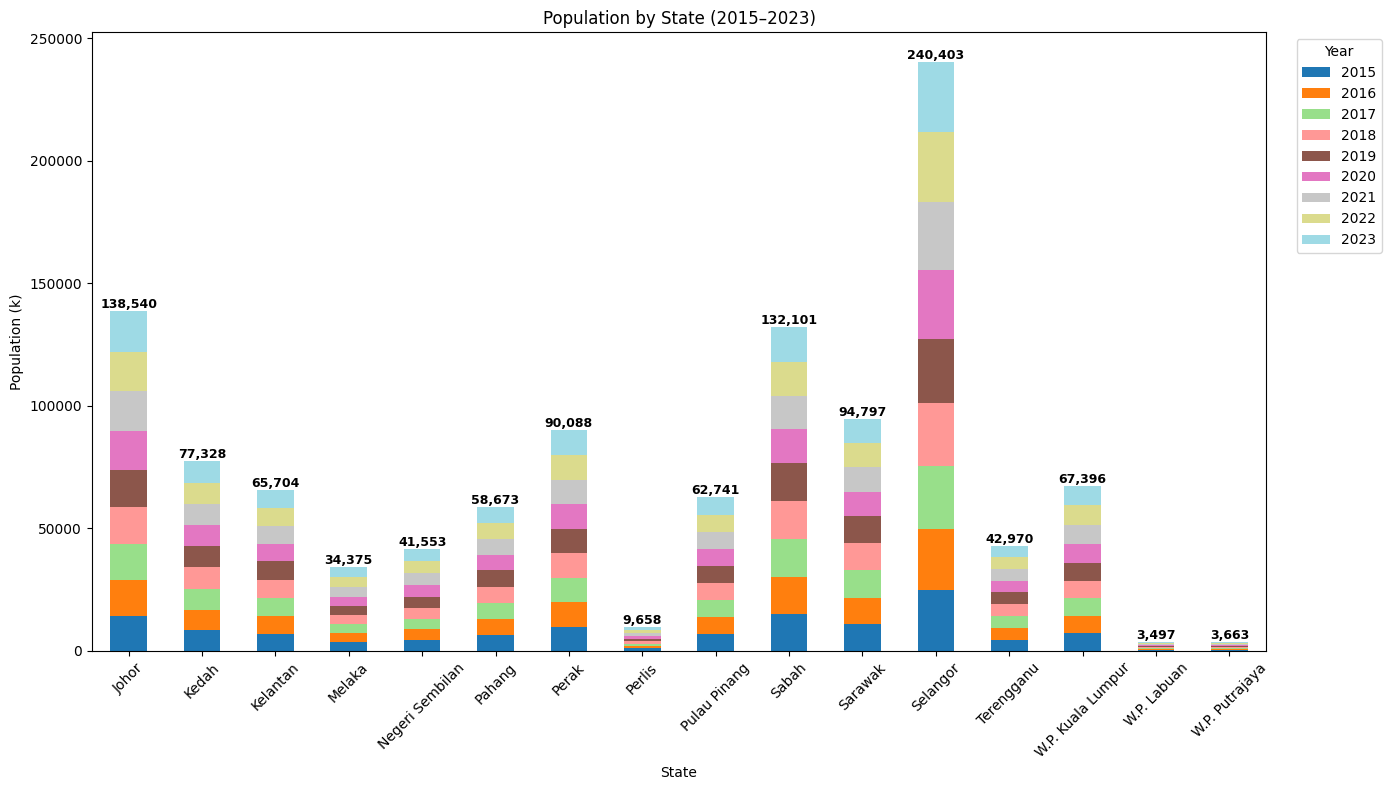

In [78]:
stack_df = merged_df.pivot_table(
    index='state',
    columns='year',
    values='population',
    aggfunc='sum'
).fillna(0)

stack_df = stack_df.sort_index()

ax = stack_df.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='tab20'
)

plt.ylabel("Population (k)")
plt.xlabel("State")
plt.title("Population by State (2015–2023)")

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)

# Show total on the top of each bar
totals = stack_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total,
        f'{total:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Plot 1 shows that population distribution across Malaysian states between 2015 and 2023 is uneven. Selangor consistently has the largest population and shows steady growth throughout the period, followed by Johor and the Federal Territory of Kuala Lumpur. Kedah and Kelantan also record relatively high population levels compared to other states, although their growth patterns are more moderate.

States such as Perlis, W.P Putrajaya and W.P. Labuan remain at the lower end of the population scale, with minimal changes over time. This contrast indicates that population growth is concentrated in a limited number of states rather than being evenly distributed nationwide.

The distribution pattern suggests that population concentration is closely associated with urbanisation and economic activity. While highly urbanised states combine large populations with strong economic performance, states such as Kedah and Kelantan demonstrate that higher population size alone does not necessarily correspond to higher economic output. This population imbalance provides important context for analysing regional economic disparities in Malaysia.

**Plot 2: Population Share by State (2023)**

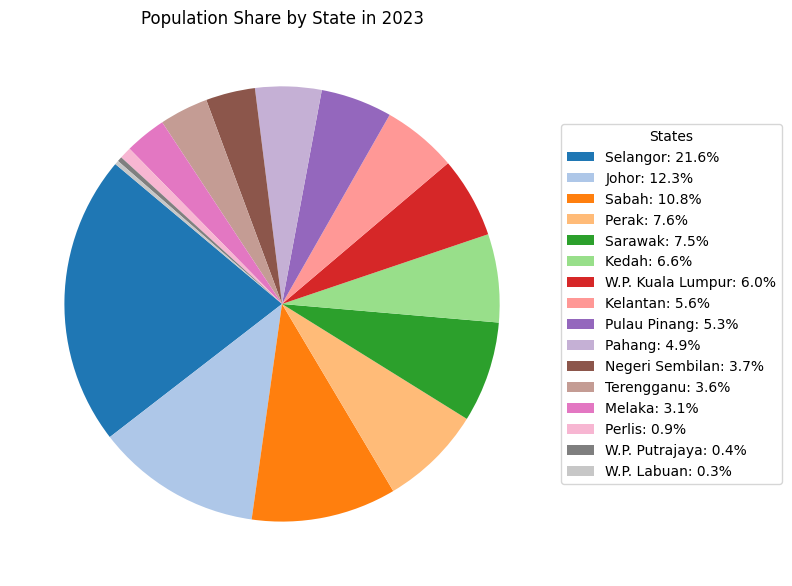

In [79]:
latest_year = merged_df['year'].max()

pop_latest = (
    merged_df[merged_df['year'] == latest_year]
    .groupby('state', as_index=False)['population']
    .sum()
)

# Calculate percentage
pop_latest['percentage'] = (
    pop_latest['population'] / pop_latest['population'].sum()
) * 100

# Sort descending for better visualization
pop_latest = pop_latest.sort_values('percentage', ascending=False)

plt.figure(figsize=(8,8))
wedges, texts = plt.pie(
    pop_latest['percentage'],
    startangle=140,
    colors=plt.cm.tab20.colors
)

legend_labels = [f'{s}: {p:.1f}%' for s, p in zip(pop_latest['state'], pop_latest['percentage'])]

plt.title(f"Population Share by State in {latest_year}")
plt.legend(wedges, legend_labels, title="States", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

The pie chart illustrates the percentage distribution of Malaysia’s population by state in the latest available year. Selangor accounts for the largest share of the national population, followed by Johor, Kedah, Kelantan, and the Federal Territory of Kuala Lumpur. Together, these states represent a substantial proportion of Malaysia’s total population, indicating strong demographic concentration.

In contrast, smaller states such as Perlis and Labuan contribute only a small percentage to the overall population. The visual emphasises that population distribution across states is uneven, with a limited number of states accounting for a large share of residents. This concentration provides important context for understanding regional economic disparities and supports further analysis of the relationship between population size and GDP.

**Plot 3: Overall GDP by State (2023)**

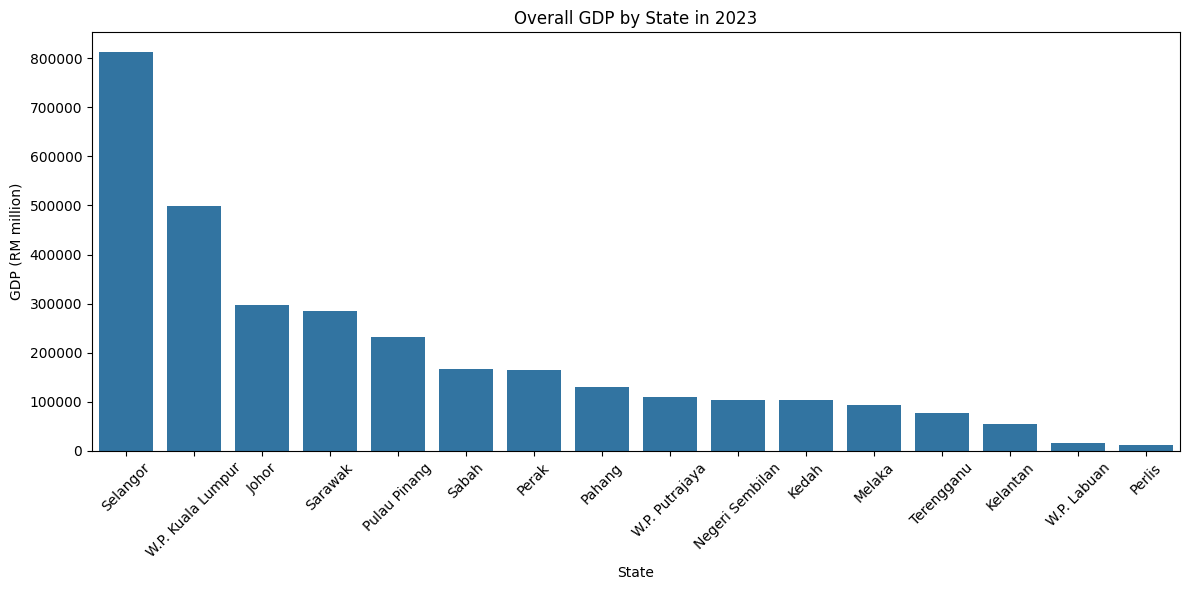

In [65]:
latest_year = merged_df['year'].max()

gdp_latest = (
    merged_df[merged_df['year'] == latest_year]
    .groupby('state', as_index=False)['value']
    .sum()
)

# Sort by GDP descending
gdp_latest = gdp_latest.sort_values('value', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=gdp_latest,
    x='state',
    y='value',
)

plt.title(f"Overall GDP by State in {latest_year}")
plt.xlabel("State")
plt.ylabel("GDP (RM million)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This bar chart presents the overall GDP by state for the latest year (2023). Selangor records the highest GDP among all states, showing a substantial gap compared to others. The Federal Territory of Kuala Lumpur and Johor follow as the second and third largest contributors, respectively. Several states, including Kedah and Kelantan, exhibit moderate GDP levels despite having relatively large populations, while smaller states such as Perlis and Labuan contribute minimally.

The distribution highlights strong economic concentration in a small number of states, particularly those with higher levels of urbanisation and industrial activity. This pattern supports the study’s hypothesis that population size is positively related to economic output, while also indicating that economic structure and sectoral composition play an important role in determining state-level GDP (Department of Statistics Malaysia, 2024).

**Plot 4: Population vs GDP (2023)**



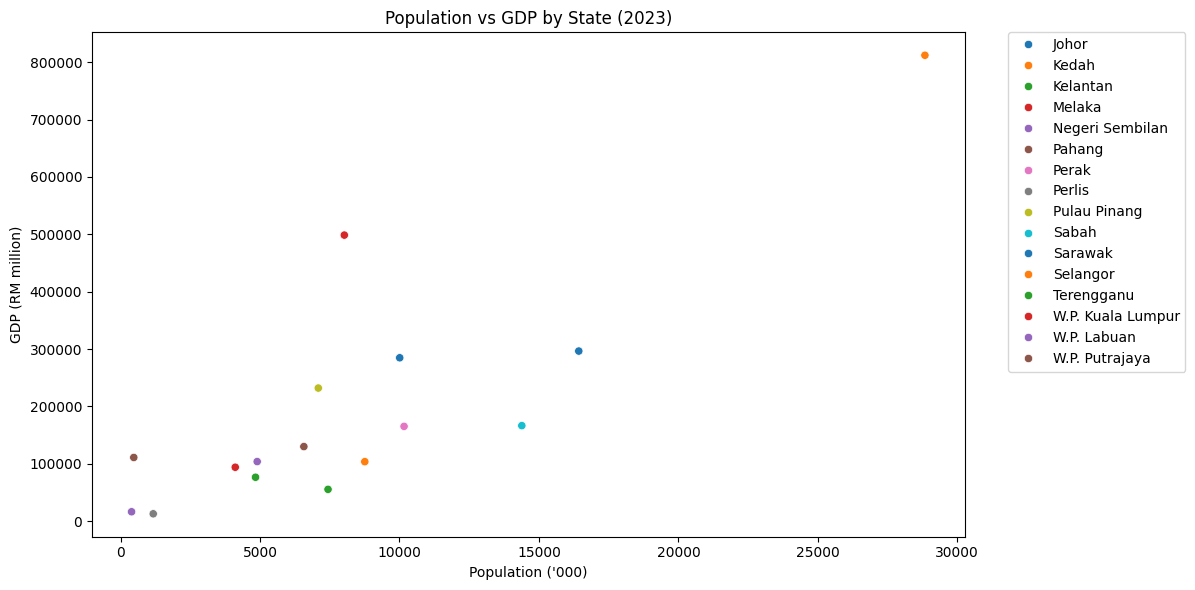

In [72]:
latest_year = merged_df['year'].max()
latest_data = merged_df[merged_df['year'] == latest_year].copy()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=latest_data,
    x='population',
    y='value',
    hue='state',
    palette='tab10'
)

plt.title(f"Population vs GDP by State ({latest_year})")
plt.xlabel("Population ('000)")
plt.ylabel("GDP (RM million)")

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

Selangor stands out as the most populous state and consistently records the highest GDP contribution, demonstrating a significant gap compared to other states. In 2023, Selangor contributed 25.9% of Malaysia’s GDP, followed by Kuala Lumpur, Johor, Sarawak, Penang, and Sabah. Together, these six states accounted for approximately 73% of the national economy, highlighting strong economic concentration. [1]

**Plot 5: Population by Age Group in Selangor (2023)**

In [67]:
latest_year = merged_df['year'].max()

selangor_pop_data = dataframes['population_state'][
    (dataframes['population_state']['state'] == 'Selangor') &
    (dataframes['population_state']['date'].dt.year == latest_year)
].copy()

# Only keep both sexes
selangor_age_df = selangor_pop_data[selangor_pop_data['sex'] == 'both']

# Exclude 'overall' age group
selangor_age_df = selangor_age_df[selangor_age_df['age'] != 'overall']

# Aggregate population by age group
selangor_age_df = selangor_age_df.groupby('age', as_index=False)['population'].sum()

# Sort age groups properly
age_order = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
             '40-44','45-49','50-54','55-59','60-64','65-69','70-74',
             '75-79','80-84','85+']

selangor_age_df['age'] = pd.Categorical(selangor_age_df['age'], categories=age_order, ordered=True)
selangor_age_df = selangor_age_df.sort_values('age')

print(selangor_age_df.head())

     age  population
0    0-4      1008.2
9    5-9      1072.8
1  10-14       983.4
2  15-19      1006.9
3  20-24      1186.5


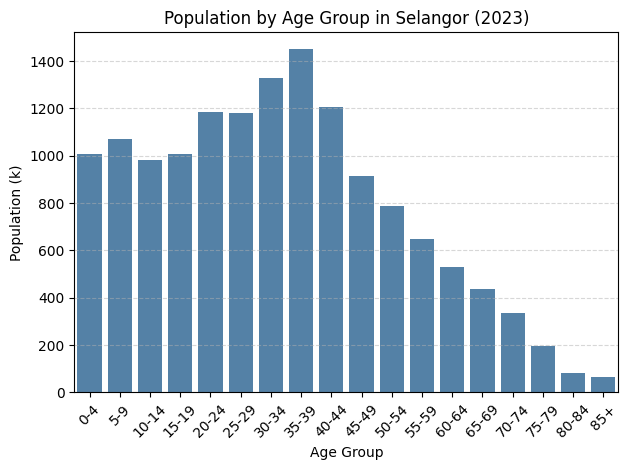

In [80]:
sns.barplot(
    x='age',
    y='population',
    data=selangor_age_df,
    color='steelblue'
)

plt.xticks(rotation=45)
plt.title(f"Population by Age Group in Selangor ({latest_year})")
plt.xlabel("Age Group")
plt.ylabel("Population (k)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The bar chart illustrates the population distribution across different age groups in Selangor for the year 2023. The working-age population, defined as individuals aged 15–64, clearly dominates the demographic profile, indicating a strong labor force available to support the state’s economic activities. Younger age groups (0–14 years) and older age groups (65 years and above) constitute a smaller proportion of the total population, suggesting a relatively moderate dependency ratio. This demographic composition highlights why Selangor consistently demonstrates robust economic performance, as a higher proportion of working-age individuals tends to correlate with increased productivity and higher GDP output. Understanding the age structure provides key insights into workforce potential and planning for social services, economic policies, and future population growth trends.

## **4.0 Recommendations**

Based on the analysis of population distribution across Malaysian states and the supporting economic insights from GDP data, several key recommendations can be made to address regional imbalances and support sustainable development.

**1. Balanced Regional Development**

The findings show that population and economic activity are highly concentrated in states such as Selangor, Johor, and Kuala Lumpur. To reduce this imbalance, policymakers should strengthen regional development initiatives in smaller states such as Perlis, Labuan, and Melaka. This can be achieved through infrastructure expansion, improved connectivity, and incentives for businesses to operate outside major urban centers.

**2. Targeted Economic Investment**

States with lower population and GDP contributions should be prioritized for targeted economic investment. Encouraging industries such as manufacturing, agriculture technology, and digital services in these regions can help stimulate job creation and reduce migration pressure toward urban areas.

**3. Data-Driven Policy Making**

The use of both Python-based analysis and Hive Views demonstrates the importance of data-driven decision-making. Government agencies should continue integrating Big Data tools such as Spark SQL and Python analytics to monitor population trends and economic performance more efficiently. This allows for faster and more accurate policy responses.

**4. Enhanced Socioeconomic Monitoring**

Future policy planning should incorporate additional indicators such as GDP per capita, employment rates, education levels, and migration patterns. This would provide a more comprehensive understanding of the relationship between population distribution and economic development.

**5. Strengthening Big Data Integration**

Although Hive Views were used as a supplementary analytical tool in this study, future work should further integrate Big Data frameworks such as Apache Spark into the core analysis pipeline. This would enable scalable processing of larger datasets and support more advanced predictive analytics.

# **5.0 Conclusion**

This study aimed to investigate whether population distribution is evenly spread across Malaysian states and whether there is an association between population size and state-level GDP. The analysis reveals that both population and economic activity are highly concentrated in a few major states, particularly Selangor, Johor, and W.P. Kuala Lumpur, while smaller states experience comparatively slower demographic and economic growth.

The findings provide evidence to reject the null hypothesis (H₀), indicating that there is a positive relationship between population size and GDP across states (H₁). In general, states with larger populations tend to generate higher economic output, suggesting that population concentration is closely linked to economic performance.

From a data science perspective, these results highlight the value of integrating population and economic datasets to uncover regional disparities and development patterns. The study demonstrates how analytical tools such as Python-based processing and Spark SQL (Hive Views) can be used to support data-driven insights.

Overall, the results suggest the need for policymakers to consider strategies that promote more balanced regional development, improve resource allocation, and support sustainable economic growth in less-populated states.

# **References**

1. Mail, M. (2024, July 2). DOSM: Selangor top contributor to Malaysia’s 2023 GDP. Malay Mail. https://www.malaymail.com/news/malaysia/2024/07/02/dosm-selangor-top-contributor-to-malaysias-2023-gdp/142535#:~:text=DoSM:%20Selangor%20top%20contributor%20to%20Malaysia's%202023%20GDP%20%7C%20Malay%20Mail